In [ ]:
import pandas as pd

# Dataset Visualization

In [ ]:
import pandas as pd
file_path = "../../data/de-escalation training dataset.xlsx"
sheet_to_load = "synthesis_dataset"
df_data = pd.read_excel(file_path, sheet_name=sheet_to_load)
df_data.head(2)

,Conversation_Id,Scenario_Number,Scenario_Title,Scenario_Context,Scenario_Set_up,Scenario_Character_Profile,Scenario_recommendation_action,de_escalation_outccome,de_escalation_score,Conversation,is_ai_generated,conversation_generator,Prompt for Generation
0,1,1.0,Mike’s Bad Day,"Units respond to River Bottoms Pub, reference ...",1.Bartender (caller) briefing: \n Greet...,"Mike, 42, construction worker. Recently lost j...",•\tMove to a tactically safe position (Distanc...,Ideal,100.0,Officer: Hey there. My name is Chris. I'm with...,yes,gemeni 2.5 pro,NaN
1,2,1.0,Mike’s Bad Day,"Units respond to River Bottoms Pub, reference ...",1.Bartender (caller) briefing: \n Greet...,"Mike, 42, construction worker. Recently lost j...",•\tMove to a tactically safe position (Distanc...,Partial,-20.0,"Officer: Mike, police department. Step away fr...",yes,gemeni 2.5 pro,NaN


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/mdhasebulhasan/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/mdhasebulhasan/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/Users/mdhasebulhasan/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 308, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
  File "/Users/mdhasebulhasan/Library/Python/3.9/lib/python/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/mdhasebulhasan/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565,

# Calculate evaluation score

In [2]:
import pandas as pd
file_path = "../../data/de-escalation training dataset.xlsx"
sheet_to_load = "de_escalation_evaluation"
df = pd.read_excel(file_path, sheet_name=sheet_to_load)
df.head()

,Conversation_Id,de_escalation_outccome,de_escalation_score,Conversation,Evaluation_SCORE_GEMINI-2.5-FLASH
0,1,Ideal,100,Officer: Hey there. My name is Chris. I'm with...,95
1,2,Partial,33,"Officer: Mike, police department. Step away fr...",10
2,3,Failure,0,"Officer: Police! Mike, show me your hands and ...",0
3,4,Ideal,100,"Officer: Mike, right? I’m Dan. I’m just here t...",99
4,5,Partial,65,"Officer: Evening, Mike. Name’s Dan. I’m not he...",75


In [3]:
df['score_difference'] = df['de_escalation_score'] - df['Evaluation_SCORE_GEMINI-2.5-FLASH']

# Group by outcome and describe the difference
stats = df.groupby('de_escalation_outccome')['score_difference'].describe()
print(stats)

                        count  mean        std   min   25%  50%   75%   max
de_escalation_outccome                                                     
Failure                  10.0  -1.6   2.412928  -7.0 -1.00 -1.0  0.00   0.0
Ideal                    10.0   3.6   3.470511   0.0  1.25  2.5  5.00  12.0
Partial                  10.0  -5.6  13.937958 -26.0 -9.50 -5.0 -0.75  23.0


Ideal - Shapiro-Wilk p-value: 0.0305
Partial - Shapiro-Wilk p-value: 0.3472
Failure - Shapiro-Wilk p-value: 0.0006


<Figure size 800x500 with 0 Axes>

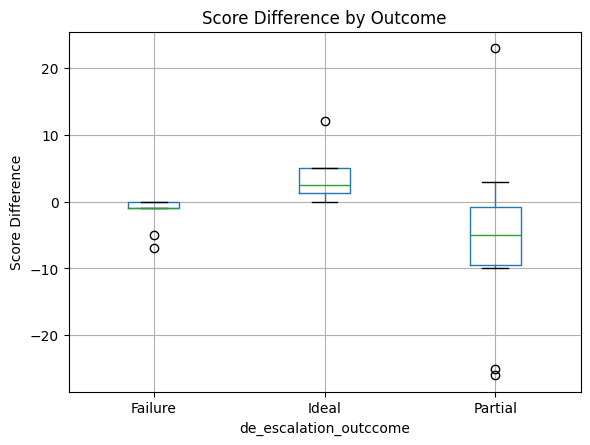

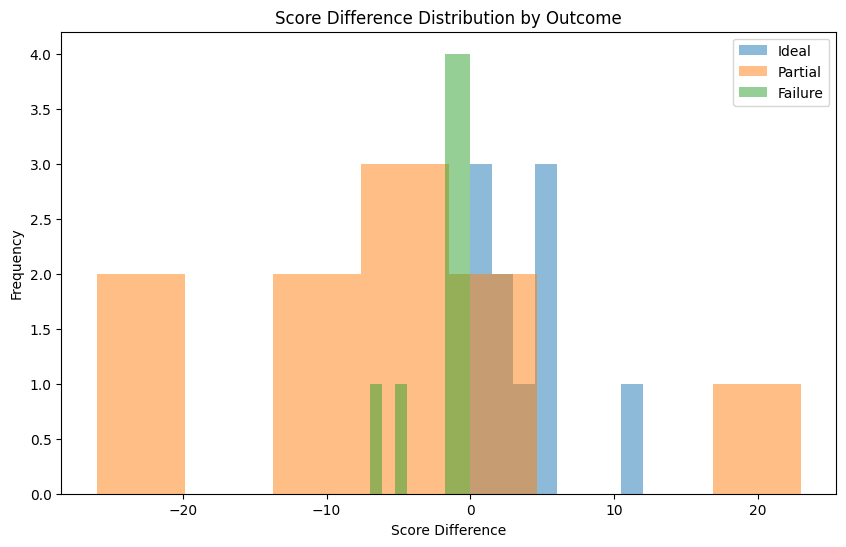

In [13]:
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Shapiro-Wilk test for normality
for outcome in df['de_escalation_outccome'].unique():
    data = df[df['de_escalation_outccome'] == outcome]['score_difference']
    stat, p = shapiro(data)
    print(f"{outcome} - Shapiro-Wilk p-value: {p:.4f}")

# Boxplot
plt.figure(figsize=(8, 5))
df.boxplot(column='score_difference', by='de_escalation_outccome')
plt.title('Score Difference by Outcome')
plt.suptitle('')
plt.ylabel('Score Difference')
plt.show()

# Histogram
plt.figure(figsize=(10, 6))
for outcome in df['de_escalation_outccome'].unique():
    data = df[df['de_escalation_outccome'] == outcome]['score_difference']
    plt.hist(data, alpha=0.5, label=outcome, bins=8)
plt.legend()
plt.title('Score Difference Distribution by Outcome')
plt.xlabel('Score Difference')
plt.ylabel('Frequency')
plt.show()

                        count  mean        std   min   25%  50%   75%   max
de_escalation_outccome                                                     
Failure                  10.0  -1.6   2.412928  -7.0 -1.00 -1.0  0.00   0.0
Ideal                    10.0   3.6   3.470511   0.0  1.25  2.5  5.00  12.0
Partial                  10.0  -5.6  13.937958 -26.0 -9.50 -5.0 -0.75  23.0


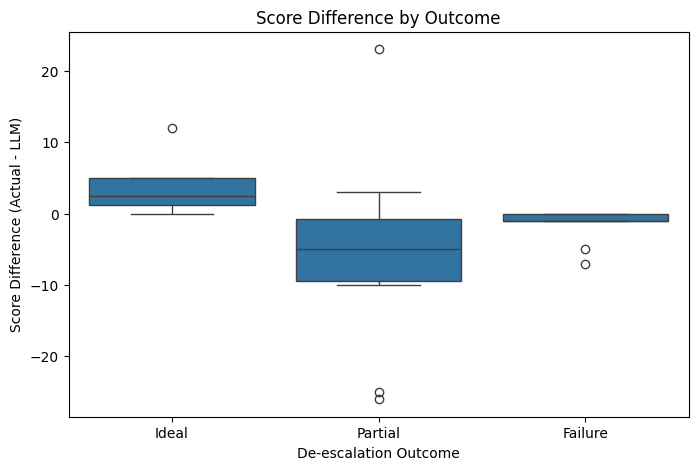

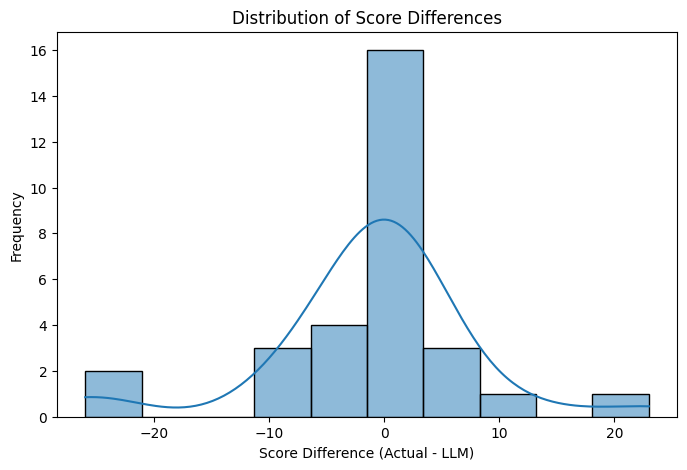

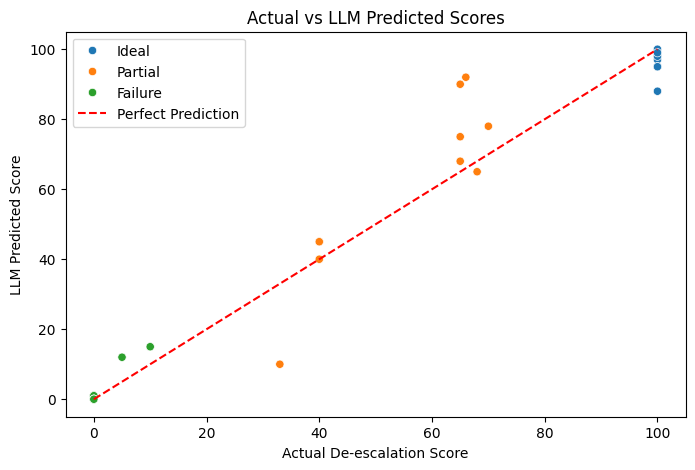

In [18]:
print(stats)

import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot of score differences by outcome
plt.figure(figsize=(8, 5))
sns.boxplot(x='de_escalation_outccome', y='score_difference', data=df)
plt.title('Score Difference by Outcome')
plt.xlabel('De-escalation Outcome')
plt.ylabel('Score Difference (Actual - LLM)')
plt.show()

# Histogram of score differences
plt.figure(figsize=(8, 5))
sns.histplot(df['score_difference'], bins=10, kde=True)
plt.title('Distribution of Score Differences')
plt.xlabel('Score Difference (Actual - LLM)')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of actual vs LLM predicted scores
plt.figure(figsize=(8, 5))
sns.scatterplot(x='de_escalation_score', y='Evaluation_SCORE_GEMINI-2.5-FLASH', hue='de_escalation_outccome', data=df)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect Prediction')
plt.title('Actual vs LLM Predicted Scores')
plt.xlabel('Actual De-escalation Score')
plt.ylabel('LLM Predicted Score')
plt.legend()
plt.show()